In [2]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [80]:
### Get results from dir

param_decoding_results_dir = Path("parameter_decoding")
results_pkls = list(param_decoding_results_dir.rglob("*/*_r2_decoding_values*.pkl"))

def extract_lambda_from_path(file_path):
    """Extract lambda value from file path/model name."""
    path_str = str(file_path)
    
    # Check if invariant is in the name - lambda = 0
    if 'inv' in path_str.lower() and 'equivariant' not in path_str.lower():
        return 0.0
    
    # Try to extract eq_lmbda pattern (e.g., eq_lmbda_5e-01)
    eq_lmbda_match = re.search(r'eq_lmbda[_-]?([\d\.]+e?-?\d*)', path_str)
    if eq_lmbda_match:
        lambda_str = eq_lmbda_match.group(1).replace('_', '-')
        try:
            # Handle scientific notation like 5e-01
            if 'e' in lambda_str.lower():
                return float(lambda_str)
            else:
                return float(lambda_str)
        except ValueError:
            pass
    
    # Try to extract lmbda pattern (e.g., lmbda_1e-2)
    lmbda_match = re.search(r'lmbda[_-]?([\d\.]+e?-?\d*)', path_str)
    if lmbda_match:
        lambda_str = lmbda_match.group(1).replace('_', '-')
        try:
            if 'e' in lambda_str.lower():
                return float(lambda_str)
            else:
                return float(lambda_str)
        except ValueError:
            pass
    
    # Default if not found
    return None

def get_training_type(file_path):
    """Determine training type from file path."""
    path_str = str(file_path).lower()
    if 'ssl' in path_str or 'barlow' in path_str or 'equi' in path_str or 'inv' in path_str:
        return 'ssl'
    else:
        # Default to supervised if it's not clearly supervised
        return 'supervised'

def get_training_set(file_path):
    """Determine training set from file path."""
    path_str = str(file_path).lower()
    
    if 'word_speaker_audioset' in path_str or 'word_speaker_noise' in path_str:
        return 'multi-task'
    elif 'audioset' in path_str and ('only' in path_str or 'unbalanced' in path_str):
        return 'unbalanced audioset'
    elif 'audioset' in path_str and 'only' not in path_str and 'unbalanced' not in path_str:
        return 'jsin audioset'
    elif 'word' in path_str and 'speaker' not in path_str and 'audioset' not in path_str:
        return 'word'
    else:
        return 'unknown'

results_dfs = []
for ix, file_path in enumerate(results_pkls):
    results_dict = pd.read_pickle(file_path)
    # get files with ridge alpha in str 

    results_df = pd.DataFrame.from_dict(results_dict)
    if 'Time shift (s)' not in results_df.index:
        continue
    results_df['parameter'] = results_df.index
    results_df.reset_index(drop=True)
    results_df['layer'] = file_path.stem.split('_r2')[0]
    results_df['model'] = 'ResNet18' if 'resnet18' in str(file_path) else 'Kell2018'
    
    # Determine training type
    results_df['training_type'] = get_training_type(file_path)
    
    # Determine training set
    results_df['training_set'] = get_training_set(file_path)
    
    # Extract lambda value
    eq_lmbda = extract_lambda_from_path(file_path)
    if eq_lmbda is not None:
        results_df['eq_lmbda'] = float(eq_lmbda)
    else:
        # Default lambda if not found (for supervised models or edge cases)
        results_df['eq_lmbda'] = '' if results_df['training_type'].iloc[0] == 'supervised' else None

    results_dfs.append(results_df)

results = pd.concat(results_dfs, axis=0, ignore_index = True).drop_duplicates()
results['training_str'] = results['training_type'] + ' ' + results['training_set'] + ' ' + results['eq_lmbda'].astype(str)
# strip trailing whitespace
results['training_str'] = results['training_str'].str.strip()

In [81]:
results.training_str.value_counts()

training_str
supervised multi-task             35
ssl unbalanced audioset 0.5       35
supervised word                   35
ssl unbalanced audioset 0.0       35
supervised unbalanced audioset    35
supervised jsin audioset          35
Name: count, dtype: int64

In [86]:
model_plot_order = [
        'supervised word',
        'supervised jsin audioset',
        'supervised unbalanced audioset',
        'supervised multi-task',
        'ssl unbalanced audioset 0.0',
        'ssl unbalanced audioset 0.5',
       ]

np.False_

## Plot Kell2018 models

Text(0.5, 1.1, 'CochCNN9 parameter decoding')

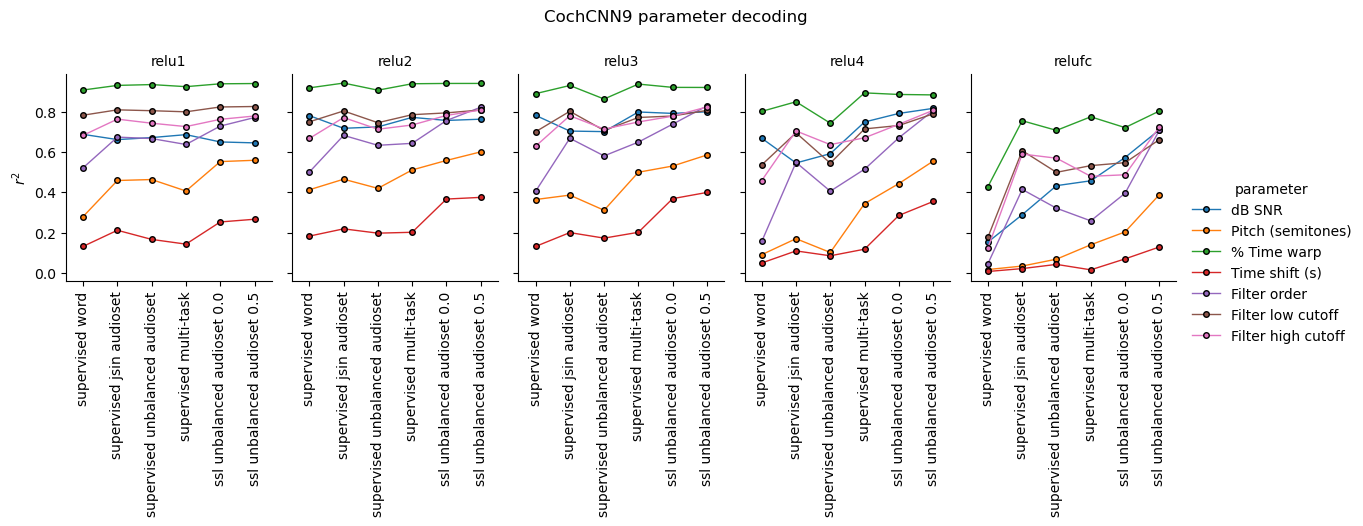

In [111]:
kell_results = results[results.model.str.contains('Kell')].reset_index(drop=True)

# fig, ax = plt.subplots(1, figsize=(6,4))
g = sns.catplot(
            kind='point',
            data=kell_results, # , [kell_results.layer=='relufc'],
            x='training_str',
            y='pr2_scores',
            order=model_plot_order,
            col='layer',
            col_order=
                ['relu1', 'relu2', 'relu3', 'relu4', 'relufc'],
            # row='model',
            # col_wrap=3,
            # errorbar=('sd'),
            hue='parameter',
            # ax=ax,
            height=3,
            aspect=0.8,
            mec='k',
            mew=1,
            lw=1, 
            ms=4
)
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(90)

g.set(ylabel='$r^2$', 
      xlabel='',
      
    #   ylim=(-0.2,1),
        # fontsize=14,
        )
g.set_titles("{col_name}")
# Reduce whitespace between panels
g.fig.subplots_adjust(wspace=0.1)
g.fig.suptitle('CochCNN9 parameter decoding', y=1.1)
# g.legend(frameon=False, fontsize=10, title='Parameter', ncol=1)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True,dpi=500,  bbox_inches='tight')
